In [1]:
import pandas as pd

In [2]:
df= pd.read_excel(r"C:\Users\ArtiR\Downloads\weather_forecast.xlsx")

In [3]:
df

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [4]:
# mlp do not support categorical data  
'''we have to change cat to numerical 
converting feature into numerical 
get dummies pandas
one hot encoding
converting target clm to numerical clm
use label encoder '''


'we have to change cat to numerical \nconverting feature into numerical \nget dummies pandas\none hot encoding\nconverting target clm to numerical clm\nuse label encoder '

In [5]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
x= df.iloc[: ,:-1]
x

,Outlook,Temperature,Humidity,Windy
0,Sunny,Hot,High,Weak
1,Sunny,Hot,High,Strong
2,Overcast,Hot,High,Weak
3,Rain,Mild,High,Weak
4,Rain,Cool,Normal,Weak
5,Rain,Cool,Normal,Strong
6,Overcast,Cool,Normal,Strong
7,Sunny,Mild,High,Weak
8,Sunny,Cool,Normal,Weak
9,Rain,Mild,Normal,Weak


In [39]:
from sklearn.preprocessing import OneHotEncoder

In [41]:
encoder=OneHotEncoder(drop='first',sparse_output=False)
x_encoded=encoder.fit_transform(x)
x_encoded

array([[0., 1., 1., 0., 0., 1.],
       [0., 1., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 1.],
       [1., 0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1., 1.],
       [1., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0., 1.],
       [0., 1., 0., 0., 1., 1.],
       [1., 0., 0., 1., 1., 1.],
       [0., 1., 0., 1., 1., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 1., 1.],
       [1., 0., 0., 1., 0., 0.]])

In [43]:
x_encoded_df=pd.DataFrame(x_encoded,columns=encoder.get_feature_names_out(x.columns))
x_encoded_df

,Outlook_Rain,Outlook_Sunny,Temperature_Hot,Temperature_Mild,Humidity_Normal,Windy_Weak
0,0.0,1.0,1.0,0.0,0.0,1.0
1,0.0,1.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0,1.0
5,1.0,0.0,0.0,0.0,1.0,0.0
6,0.0,0.0,0.0,0.0,1.0,0.0
7,0.0,1.0,0.0,1.0,0.0,1.0
8,0.0,1.0,0.0,0.0,1.0,1.0
9,1.0,0.0,0.0,1.0,1.0,1.0


In [45]:
x_encoded.shape

(14, 6)

In [47]:
y= df.iloc[:,-1]
y

0      No
1      No
2     Yes
3     Yes
4     Yes
5      No
6     Yes
7      No
8     Yes
9     Yes
10    Yes
11    Yes
12    Yes
13     No
Name: Play, dtype: object

In [49]:
from sklearn.preprocessing import LabelEncoder

In [51]:
le=LabelEncoder()
y_encoded=le.fit_transform(y)
y_encoded

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

In [55]:
from sklearn.model_selection import train_test_split

In [59]:
x_train,x_test,y_train,y_test=train_test_split(x_encoded_df,y_encoded,test_size=0.2,random_state=32)

In [ ]:
from skelarn.tree import DecisionTreeClassifier

In [63]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((11, 6), (3, 6), (11,), (3,))

In [69]:
from sklearn.tree import DecisionTreeClassifier
d=DecisionTreeClassifier(criterion='entropy')
d.fit(x_train,y_train)
y_train_pre=d.predict(x_train)

In [79]:
from sklearn.metrics import confusion_matrix,classification_report

In [81]:
confusion_matrix

<function sklearn.metrics._classification.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)>

In [87]:
y_test_pred= d.predict(x_test)

In [89]:
confusion_matrix(y_test,y_test_pred)

array([[2, 0],
       [0, 1]], dtype=int64)

In [93]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [97]:
from sklearn import tree
import matplotlib.pyplot as plt

[Text(0.5555555555555556, 0.875, 'x[1] <= 0.5\nentropy = 0.845\nsamples = 11\nvalue = [3, 8]'),
 Text(0.3333333333333333, 0.625, 'x[5] <= 0.5\nentropy = 0.592\nsamples = 7\nvalue = [1, 6]'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'x[0] <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1111111111111111, 0.125, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3333333333333333, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4444444444444444, 0.375, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.7777777777777778, 0.625, 'x[4] <= 0.5\nentropy = 1.0\nsamples = 4\nvalue = [2, 2]'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8888888888888888, 0.375, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]')]

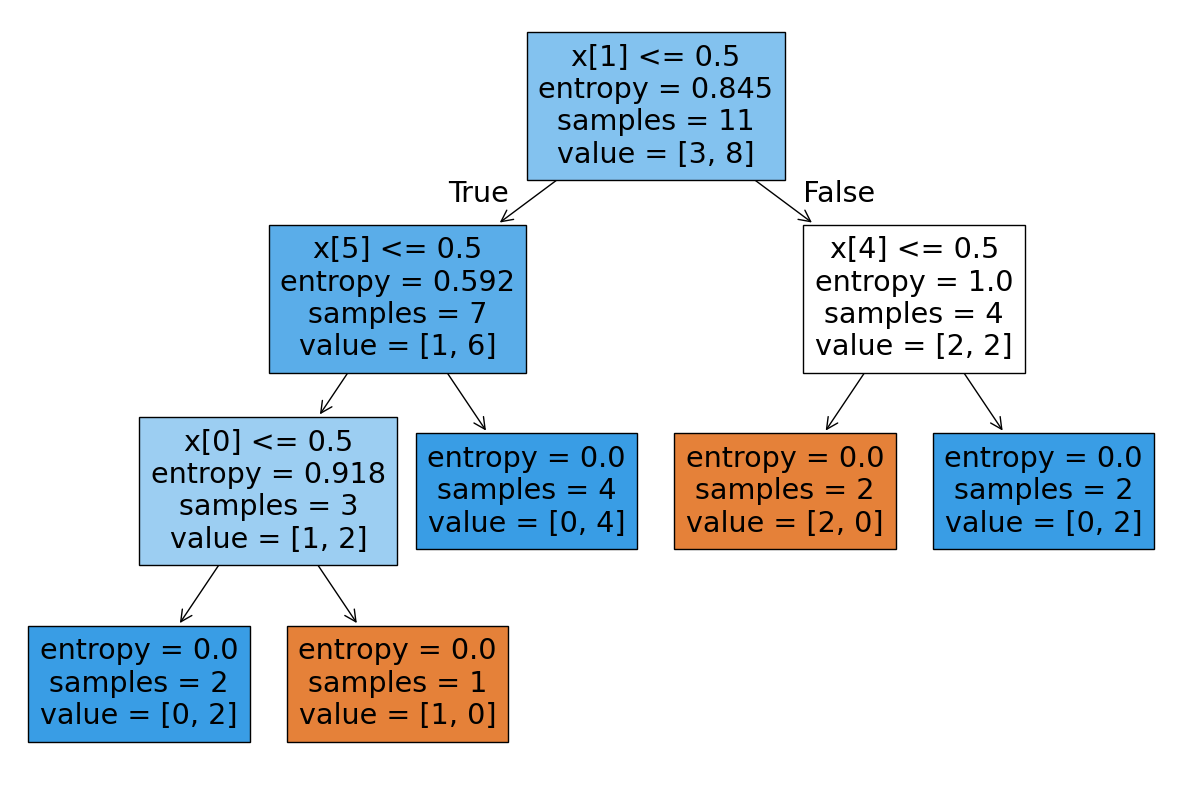

In [99]:

plt.figure(figsize=(15,10))
tree.plot_tree(d,filled=True)


In [3]:
import pandas as pd

In [5]:
df1= pd.read_csv(r"D:\All data\Iris.csv")

df1

In [8]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [14]:
df1.shape

(150, 6)

In [20]:
df= df1.drop('Id',axis =1)

In [22]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [34]:
from sklearn .preprocessing import OneHotEncoder

In [36]:
x= df.iloc[:,:-1]
x

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [38]:
encoder = OneHotEncoder(drop="first", sparse_output = False)
x_encoded = encoder.fit_transform(x)
x_encoded

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [44]:
x_encoded_df= pd.DataFrame(x_encoded,columns = encoder .get_feature_names_out(x.columns))
x_encoded_df

,SepalLengthCm_4.4,SepalLengthCm_4.5,SepalLengthCm_4.6,SepalLengthCm_4.7,SepalLengthCm_4.8,SepalLengthCm_4.9,SepalLengthCm_5.0,SepalLengthCm_5.1,SepalLengthCm_5.2,SepalLengthCm_5.3,...,PetalWidthCm_1.6,PetalWidthCm_1.7,PetalWidthCm_1.8,PetalWidthCm_1.9,PetalWidthCm_2.0,PetalWidthCm_2.1,PetalWidthCm_2.2,PetalWidthCm_2.3,PetalWidthCm_2.4,PetalWidthCm_2.5
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
148,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [46]:
x_encoded.shape

(150, 119)

In [50]:
y=df.iloc[:,-1]
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object

In [52]:
y= df.iloc[:,-1]
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object

In [56]:
from sklearn.preprocessing import LabelEncoder

In [58]:
le= LabelEncoder()
y_encoded= le.fit_transform(y)
y_encoded

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [64]:
x_train,x_test,y_train,y_test=train_test_split(x_encoded_df,y_encoded,test_size=0.2,random_state=32)

In [62]:
from sklearn.model_selection import train_test_split

In [70]:
from sklearn.tree import DecisionTreeClassifier

In [72]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((120, 119), (30, 119), (120,), (30,))

In [74]:
from sklearn.tree import DecisionTreeClassifier
d=DecisionTreeClassifier(criterion='entropy')
d.fit(x_train,y_train)
y_train_pre=d.predict(x_train)

In [76]:
from sklearn.metrics import confusion_matrix,classification_report

In [78]:
confusion_matrix

<function sklearn.metrics._classification.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)>

In [80]:
y_test_pred= d.predict(x_test)

In [82]:
confusion_matrix(y_test,y_test_pred)

array([[8, 0, 4],
       [0, 8, 1],
       [0, 2, 7]], dtype=int64)

In [84]:
array([[2, 0],
       [0, 1]], dtype=int64)

NameError: name 'array' is not defined

In [86]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80        12
           1       0.80      0.89      0.84         9
           2       0.58      0.78      0.67         9

    accuracy                           0.77        30
   macro avg       0.79      0.78      0.77        30
weighted avg       0.81      0.77      0.77        30



In [88]:
from sklearn import tree
import matplotlib.pyplot as plt